# 11 · SAR

Template para el modelo autoregresivo espacial implementado en `SpatialAutoregressiveModel`.

## Hipótesis del modelo

- Parte del precio se explica por dependencia espacial entre propiedades cercanas.
- El parámetro espacial `rho` debería capturar interacción local no absorbida por las covariables.
- La interpretación principal viene por coeficientes globales, `rho` y patrones de residuos.

In [ ]:
from pathlib import Path
import sys
import pandas as pd
import geopandas as gpd
import seaborn as sns


PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from ml_core.models.sarModel import SpatialAutoregressiveModel
from ml_core.evaluation.modelEvaluator import regression_metrics
from ml_core.visualization.mapper import *

OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "output" / "11_sar"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")

## Datos y split

In [ ]:
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "rental_listings_model_input.parquet"
DATA_PATH = PROJECT_ROOT / "data" / "splits"

train_raw = pd.read_csv(DATA_PATH / "arg_venta_caba_train.csv")
gdf_train = gpd.GeoDataFrame(
    train_raw,
    geometry=gpd.points_from_xy(
        train_raw["longitud"],
        train_raw["latitud"]
    ),
    crs="EPSG:4326"
)

test_raw = pd.read_csv(DATA_PATH / "arg_venta_caba_test.csv")
gdf_test = gpd.GeoDataFrame(
    test_raw,
    geometry=gpd.points_from_xy(
        test_raw["longitud"],
        test_raw["latitud"]
    ),
    crs="EPSG:4326"
)

val_raw = pd.read_csv(DATA_PATH / "arg_venta_caba_val.csv")
gdf_val = gpd.GeoDataFrame(
    val_raw,
    geometry=gpd.points_from_xy(
        val_raw["longitud"],
        val_raw["latitud"]
    ),
    crs="EPSG:4326"
)

target_col = "log_precio"
coord_cols = ["longitud", "latitud"]
feature_cols = [
    'area_m2_total',
    'area_m2_descubierta',
    'ambientes',
    'antiguedad',
    'expensas',
    'banos',
    'cocheras',
    'estado_num',
    'disposicion_Frente',
    'disposicion_Contrafrente',
    'disposicion_Lateral'
]


feature_cols_to_std = [
    'area_m2_total',
    'area_m2_descubierta',
    'ambientes',
    'antiguedad',
    'expensas',
]


In [ ]:
X_train = gdf_train[feature_cols]
y_train = gdf_train[target_col]
coords_train = gdf_train[coord_cols].to_numpy()

X_test = gdf_test[feature_cols]
y_test = gdf_test[target_col]
coords_test = gdf_test[coord_cols].to_numpy()

X_val = gdf_val[feature_cols]
y_val = gdf_val[target_col]
coords_val = gdf_val[coord_cols].to_numpy()

## Entrenamiento

In [ ]:
sar_config = {"k": 5}
model = SpatialAutoregressiveModel(sar_config=sar_config)
model.fit(X_train, y_train, coords_train)
model


/home/saneliges/Escritorio/PredictorPrecioMetroCuadradoAlquileres/.venv/lib/python3.12/site-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 15 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


ML_Lag


## Sensibilidad de hiperparámetros

Acá conviene comparar distintos valores de `k` y, si querés, distintas definiciones de vecindad.

In [ ]:

model.tune_hyperparameters(X_test, y_test.values.reshape(-1, 1), coords_test)
best_config = {"gwr_params": sar_config, "selected_k": getattr(model, "k_", None)}
best_config


ML_Lag
ML_Lag
ML_Lag
ML_Lag
ML_Lag
ML_Lag


{'gwr_params': {'k': 5}, 'selected_k': 5}

## Evaluación global

In [ ]:
y_pred_log = model.predict(
    X_val,
    coords_val
)

# revertir log
y_pred = np.exp(y_pred_log)
y_true = np.exp(y_val)

metrics = regression_metrics(
    y_true,
    y_pred
)

metrics

{'rmse': 0.47487828701506324,
 'mae': 0.2731679160641588,
 'r2': 0.5866707372471176,
 'bias': 0.012605573650087225,
 'median_abs_error': 0.19831757378571346,
 'mape': 2.249547599758444}

## Visualización

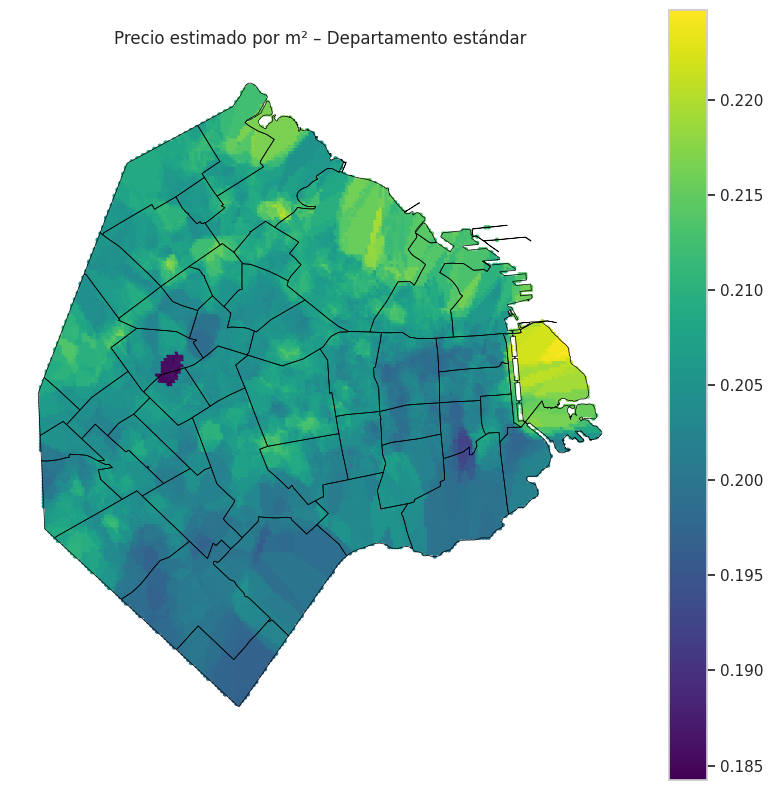

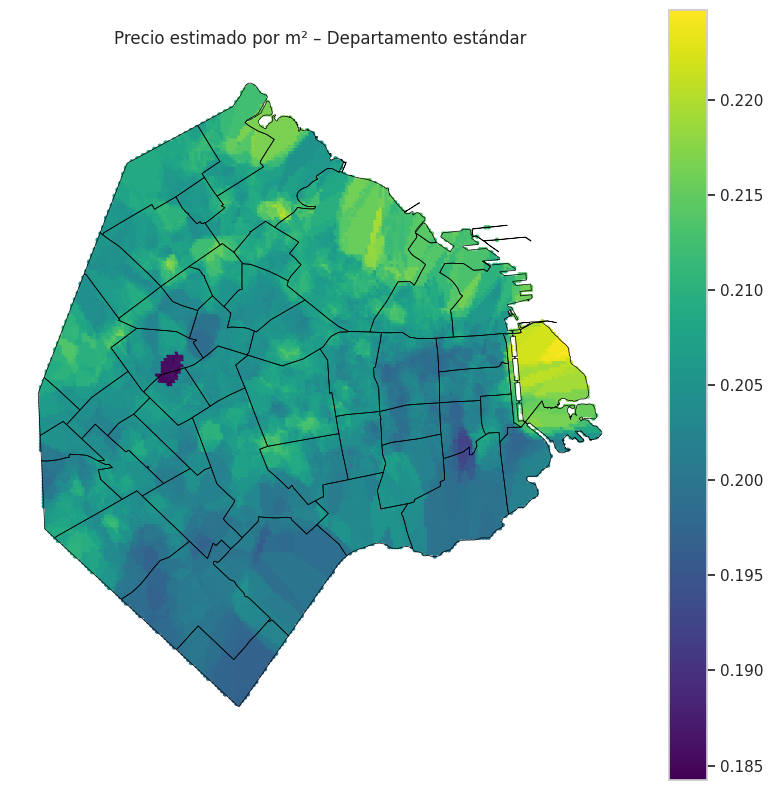

In [ ]:
barrios_path = PROJECT_ROOT / 'barrios.geojson'

df_grid, barrios, std = generar_grid_predicciones(
    model,
    gdf_val,
    feature_cols
)

mapa = MapaPrecio(df_grid, barrios)

mapa.plot()

#mapa.save("mapa_modelo_lgwr.png")

#mapa.save("mapa_modelo_lgwr.pdf")



## Interpretación

A diferencia de GWR, SAR tiene una interpretación más global:

- coeficientes globales
- magnitud y signo de `rho`
- sensibilidad al número de vecinos
- concentración espacial de residuos

In [31]:
# coef_frame = pd.DataFrame({
#     "feature": ["intercept"] + feature_cols + ["rho"],
#     "coefficient": np.asarray(model.model_.betas).reshape(-1),
# })
# coef_frame

## Residuos y export

In [32]:
# test_export = test_df[[target_col] + coord_cols].copy()
# test_export = test_export.rename(columns={target_col: "y_true"})
# test_export["y_pred"] = np.asarray(y_pred).reshape(-1)
# test_export["residual"] = test_export["y_true"] - test_export["y_pred"]
# test_export["split"] = "test"
# test_export.to_parquet(OUTPUT_DIR / "test_predictions.parquet", index=False)
# coef_frame.to_parquet(OUTPUT_DIR / "interpretability.parquet", index=False)
# (OUTPUT_DIR / "metrics.json").write_text(json.dumps(metrics, indent=2, ensure_ascii=False))
# (OUTPUT_DIR / "run_config.json").write_text(json.dumps(sar_config, indent=2, ensure_ascii=False))